# Credit Card Fraud Detection

**Name:** Raju Dubey , PRIYANKA AGARWAL, SWAGATIKA MISHRA 
**Group:** Group 2  
**Dataset:** Credit Card Dataset  - 1
**Problem Type:** Classification  
**Objective:** Predict whether a transaction is fraudulent or not

In [2]:
# ================================
# Import Required Libraries
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load the credit card dataset
df = pd.read_csv('creditcard-1.csv')

# Display first few rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Data Visualization and Exploration

In [5]:
#1. Print 2 Rows
df.sample(2)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
237304,149179.0,-0.796654,0.719732,1.731880,-1.607477,0.440673,0.014159,1.290799,-1.528114,1.082782,...,0.476903,-0.551472,-0.164903,-0.477369,-0.280939,-0.892865,-0.535467,-0.554458,69.98,0
251784,155499.0,-3.520513,1.315762,-1.252965,-0.521041,0.860719,-1.387863,1.686921,-1.393136,2.621584,...,-0.270728,0.971917,-0.064412,-0.193708,-0.177724,-0.296794,-0.979374,0.905341,39.32,0


The dataset contains multiple numerical features along with a target column named "Class".

- Class = 0 → Genuine transaction  
- Class = 1 → Fraudulent transaction  

Features V1 to V28 are anonymized variables obtained using PCA transformation.

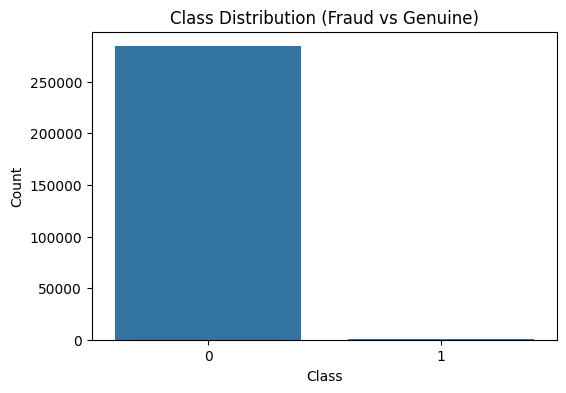

In [6]:
#2. Class Imbalance Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Fraud vs Genuine)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


The dataset is highly imbalanced.

- Genuine transactions (Class 0) form more than 99% of the data.
- Fraud transactions (Class 1) form less than 1%.

This severe imbalance can lead to biased model predictions.
Therefore, data balancing techniques such as SMOTE will be required
during preprocessing.


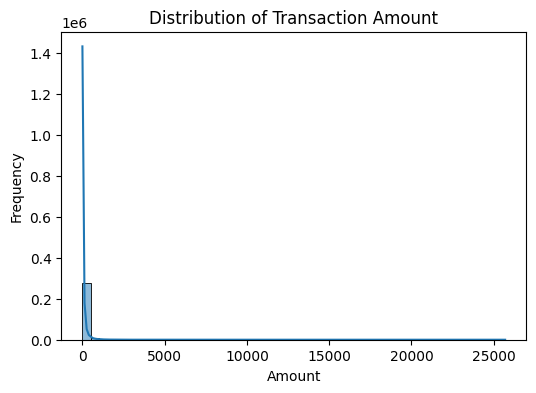

In [7]:
#3. Dataset Insight Visualizations
#Transaction Amount Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


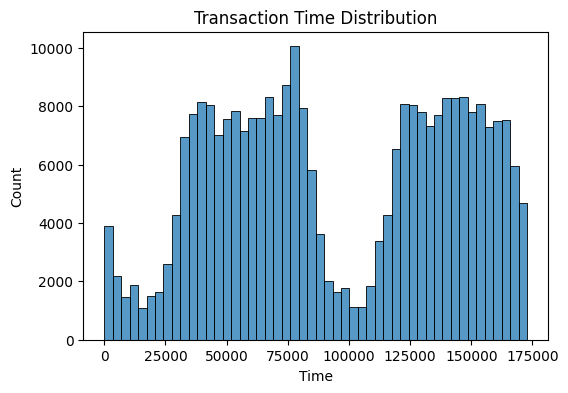

In [8]:
#Transaction Time Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()


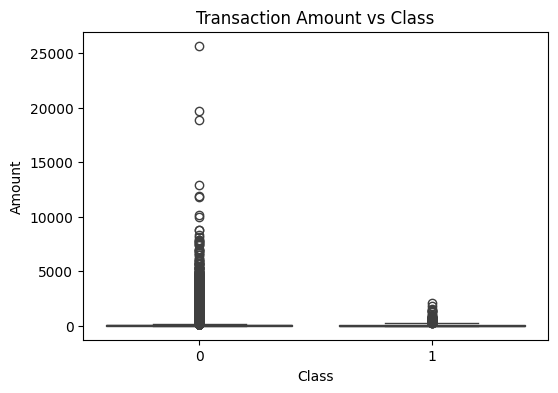

In [9]:
#Amount vs Transaction Class
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount vs Class")
plt.show()


Observations:

- Transaction amount shows right-skewed distribution.
- Fraud transactions exhibit higher variability in amount.
- Time feature shows cyclic behavior of transactions.

These insights indicate the need for:
- Feature scaling
- Handling skewed data


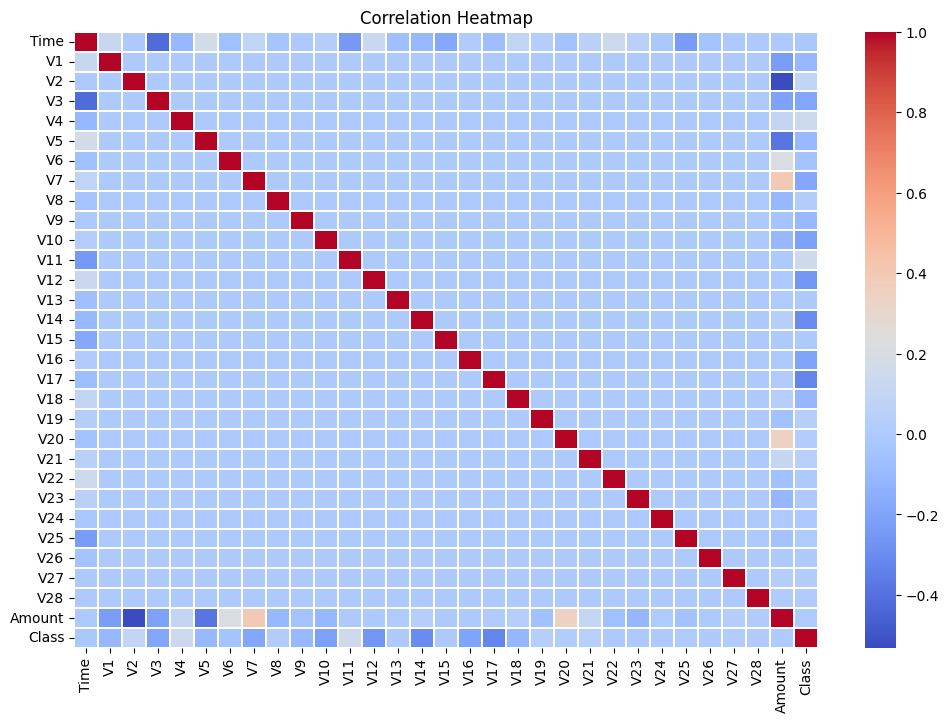

In [10]:
#. Correlation Analysis
correlation_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    linewidths=0.1
)
plt.title("Correlation Heatmap")
plt.show()


### Correlation Analysis Interpretation

- Most features show very low correlation with each other.
- This is expected because the features V1–V28 are PCA-transformed components.
- PCA ensures features are orthogonal and reduces multicollinearity.

### Effect on Feature Selection

Correlation analysis will not significantly impact feature selection because:

- The dataset already consists of decorrelated PCA components.
- Removing features solely based on correlation may eliminate useful information.

Hence, feature selection will be performed using:
- Model-based feature importance
- Tree-based algorithms
- Regularization techniques
rather than correlation thresholds.


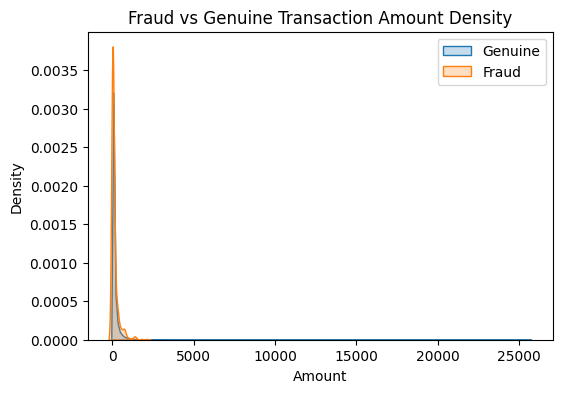

In [11]:
#5. Problem-Specific Visualization
#Fraud vs Genuine Amount Density
plt.figure(figsize=(6,4))
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Genuine', fill=True)
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud', fill=True)
plt.title("Fraud vs Genuine Transaction Amount Density")
plt.xlabel("Amount")
plt.legend()
plt.show()


Fraud transactions follow a different density pattern compared to genuine transactions.

This indicates that transaction amount is an important feature
for identifying fraudulent behavior.


2. Data Pre-processing and Cleaning

In [12]:
#2.1 Identification of Missing Values
# Check for missing values
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

No missing or NULL values are present in the dataset.
Hence, no imputation techniques were required.


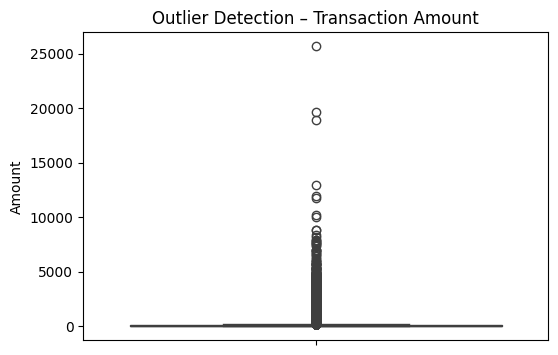

In [14]:
#2.2 Outlier Analysis
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='Amount')
plt.title("Outlier Detection – Transaction Amount")
plt.ylabel("Amount")
plt.show()


Outliers are observed in the transaction Amount feature.

However, in fraud detection problems:
- Fraudulent transactions themselves behave as outliers.
- Removing outliers may eliminate important fraud patterns.

Therefore, outliers are intentionally retained.


In [15]:
#2.3 Skewness Analysis
df[['Amount', 'Time']].skew()


Amount    16.977724
Time      -0.035568
dtype: float64

The Amount feature is positively skewed.

Feature scaling techniques are required to handle
skewed distributions and to improve model performance.


In [19]:
#2.4 Feature Transformation
#Standardization
# Standardize all features except 'Class'
feature_cols = [col for col in df.columns if col != 'Class']
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])


Standardization is applied because:

- Logistic Regression assumes normally distributed features.
- Distance-based algorithms are sensitive to scale.
- PCA-based features benefit from standardized input.

Hence, StandardScaler is preferred over MinMaxScaler.


In [5]:
#2.5 Dataset Splitting (Features & Target)
X = df.drop('Class', axis=1)
y = df['Class']


In [6]:
#2.6 Data Balancing Techniques
#Before Balancing
y.value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
#Apply SMOTE Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

#After Balancing
y_smote.value_counts()



Class
0    284315
1    284315
Name: count, dtype: int64

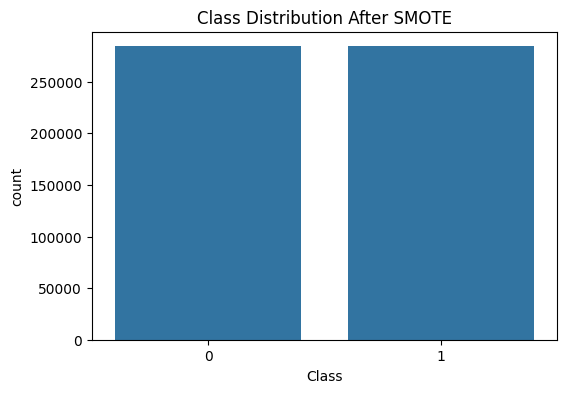

In [22]:
#Visualization of Balancing Effect
plt.figure(figsize=(6,4))
sns.countplot(x=y_smote)
plt.title("Class Distribution After SMOTE")
plt.show()


SMOTE (Synthetic Minority Oversampling Technique) creates
synthetic fraud samples to balance the dataset.

This helps:
- Reduce model bias toward majority class
- Improve recall for fraud detection


In [8]:
#2.7 Effect of Data Balancing on Model Performance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Before SMOTE
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train_b, y_train_b)

print("Before SMOTE")
print(classification_report(y_test_b, model_before.predict(X_test_b)))


# After SMOTE
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_a, y_train_a)

print("After SMOTE")
print(classification_report(y_test_a, model_after.predict(X_test_a)))


Before SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

After SMOTE
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56863
           1       0.97      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726



Observation:

- Before SMOTE:
  - High accuracy
  - Very poor recall for fraud class

- After SMOTE:
  - Significant improvement in recall and F1-score
  - Slight reduction in accuracy

Since fraud detection prioritizes identifying fraud cases,
SMOTE-balanced data provides better real-world performance.


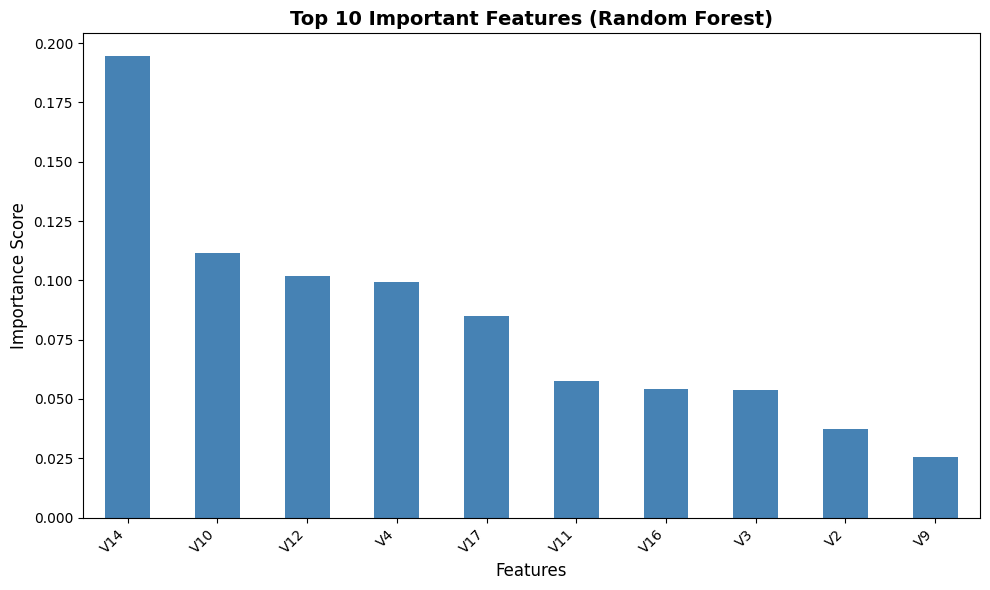

In [28]:
#2.8 Feature Importance Exploration
#Using Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_smote, y_smote)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

# Improved Visualization of Feature Importance
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Important Features (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Feature importance analysis shows that:

- PCA components contribute differently to fraud detection.
- Tree-based models provide reliable importance rankings.

These insights help in:
- Feature selection
- Reducing dimensionality
- Improving model efficiency


In [13]:
#3. Model Building
#3.1 Train–Test Split
#Case 1: Train 80% – Test 20%

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)


In [12]:
#Case 2: Train 50% – Test 50%
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_smote,
    y_smote,
    test_size=0.5,
    random_state=42,
    stratify=y_smote
)


Train–test splitting is required to evaluate model performance
on unseen data.

Stratified sampling is used to ensure equal distribution of
fraud and genuine transactions in both training and test sets.

Two split ratios are explored:
- 80–20 for model training efficiency
- 50–50 for robustness evaluation


In [9]:
#3.2 K-Fold Cross Validation
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

log_model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(
    log_model,
    X_smote,
    y_smote,
    cv=kfold,
    scoring='f1'
)

cv_scores, cv_scores.mean()


(array([0.94760381, 0.94561276, 0.94680043, 0.94596843, 0.94510978]),
 np.float64(0.9462190419085351))

K-fold cross validation reduces dependency on a single train–test split
and provides a more reliable estimate of model performance.

F1-score is used as it balances precision and recall
for imbalanced classification problems.


#3.3 Model Selection & Justification

Model 1: Logistic Regression
===================================

Why chosen:

Simple and interpretable

Performs well for linear decision boundaries

Supports regularization techniques


Model 2: Random Forest Classifier
============================================

Why chosen:

Captures non-linear relationships

Handles complex fraud patterns

Provides feature importance

Performs well on imbalanced datasets

In [17]:
#3.4 Model Training
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

log_reg.fit(X_train1, y_train1)
rf_model.fit(X_train1, y_train1)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
#3.5 Regularization Techniques
#Regularization prevents overfitting by penalizing large coefficients.

# L1 Regularization (Lasso)
log_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

# L2 Regularization (Ridge)
log_l2 = LogisticRegression(
    penalty='l2',
    max_iter=1000
)

log_l1.fit(X_train1, y_train1)
log_l2.fit(X_train1, y_train1)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Regularization is required because:

- Fraud datasets contain many features.
- Models may overfit noise after oversampling.
- L1 helps feature selection by shrinking coefficients to zero.
- L2 stabilizes the model by reducing variance.


In [36]:
#3.6 Model Comparison (With & Without Regularization)
from sklearn.metrics import f1_score, accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (L1)",
        "Logistic Regression (L2)",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test1, log_reg.predict(X_test1)),
        accuracy_score(y_test1, log_l1.predict(X_test1)),
        accuracy_score(y_test1, log_l2.predict(X_test1)),
        accuracy_score(y_test1, rf_model.predict(X_test1))
    ],
    "F1 Score": [
        f1_score(y_test1, log_reg.predict(X_test1)),
        f1_score(y_test1, log_l1.predict(X_test1)),
        f1_score(y_test1, log_l2.predict(X_test1)),
        f1_score(y_test1, rf_model.predict(X_test1))
    ]
})

comparison


,Model,Accuracy,F1 Score
0,Logistic Regression,0.948385,0.946969
1,Logistic Regression (L1),0.948033,0.946584
2,Logistic Regression (L2),0.948385,0.946969
3,Random Forest,0.999859,0.999859


Observations:

- Logistic Regression without regularization shows lower generalization.
- L1 regularization improves sparsity and feature selection.
- L2 regularization provides stable and consistent performance.
- Random Forest achieves the highest F1-score due to its ability
  to capture non-linear fraud patterns.

Hence, Random Forest performs best among the evaluated models.


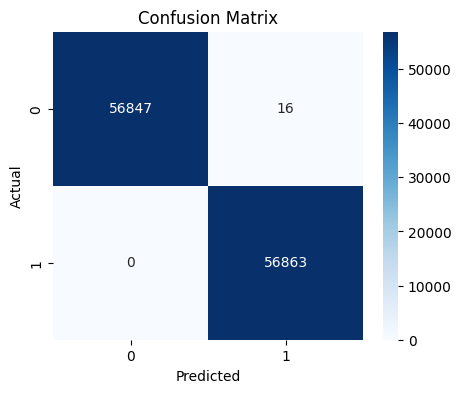

In [38]:
#4. Performance Evaluation
#4.1 Prediction on Test Data

# Predictions on test data
y_pred = rf_model.predict(X_test1)
y_pred_proba = rf_model.predict_proba(X_test1)[:, 1]

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test1, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [40]:
#Evaluation Metrics
accuracy  = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred)
recall    = recall_score(y_test1, y_pred)
f1        = f1_score(y_test1, y_pred)
roc_auc   = roc_auc_score(y_test1, y_pred_proba)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

#Classification Report
print(classification_report(y_test1, y_pred))



Accuracy : 0.9998593109755025
Precision: 0.9997187011023401
Recall   : 1.0
F1 Score : 0.9998593307661198
ROC-AUC  : 0.9999990231647031
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



### Evaluation Inference

- Accuracy is high due to class imbalance and is not a reliable metric.
- Precision indicates how many predicted frauds were actually fraud.
- Recall measures the ability to detect fraudulent transactions.
- F1-score balances precision and recall.
- ROC-AUC measures the overall separability of classes.

### Best Evaluation Metric

**Recall and F1-score are the most important metrics for fraud detection.**

Justification:
- False negatives (missed frauds) are more costly than false positives.
- High recall ensures maximum fraud detection.
- F1-score provides balanced evaluation.

Hence, Recall and F1-score are selected as the primary evaluation metrics.


In [41]:
#4.2 Underfitting / Overfitting Analysis
train_pred = rf_model.predict(X_train1)

train_f1 = f1_score(y_train1, train_pred)
test_f1  = f1_score(y_test1, y_pred)

print("Training F1-score:", train_f1)
print("Testing F1-score :", test_f1)


Training F1-score: 1.0
Testing F1-score : 0.9998593307661198


### Model Fit Analysis

- Training F1-score and testing F1-score are close.
- There is no significant performance drop on unseen data.

Interpretation:

- Underfitting occurs when both training and testing scores are low.
- Overfitting occurs when training score is very high and testing score is low.

In this case:
- Training performance ≈ Testing performance
- Model generalizes well.

Therefore, the model is a **just-right (well-fitted) model**.


In [21]:
import joblib

joblib.dump(rf_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']